# DenseNet121 Baseline Model for Medical Deepfake Detection

This notebook implements a transfer learning approach using DenseNet121 to classify CT scan slices from the Medical Deepfakes Lung Cancer dataset.

## Model Architecture Overview:
1. **Base Model**: DenseNet121 pretrained on ImageNet (frozen)
2. **Custom Head**: Global Average Pooling → Dense(256) → Dropout(0.4) → Dense(4)
3. **Data Augmentation**: Random horizontal flip and rotation
4. **Output**: 4-class classification (TB, TM, FB, FM)

## Pipeline Steps:
1. Mount Google Drive and load dependencies
2. Load and split dataset (70% train, 15% val, 15% test)
3. Create balanced class subsets to handle class imbalance
4. Build and compile DenseNet121 model
5. Train with validation monitoring
6. Evaluate on validation and test sets
7. Generate performance metrics and visualizations

In [ ]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import Required Libraries

Import TensorFlow/Keras for model building and training, along with visualization and evaluation tools.

In [ ]:
import os

# Import TensorFlow AFTER environment variables are set
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt

# Model and dataset imports
from tensorflow.keras import layers, models
from keras.models import Sequential
from tensorflow.keras.applications import VGG16, DenseNet121
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.utils import image_dataset_from_directory, Sequence
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam

## Dataset Loading and Splitting

Load the complete dataset and split into training (70%), validation (15%), and test (15%) sets.

**Important**: We load the dataset without batching first, then properly shuffle and split to ensure:
- No data leakage between sets
- Reproducible splits with seed=123
- Fair evaluation on held-out test data

In [ ]:
# Load the FULL dataset first (no split)
# batch_size=None ensures we load individual samples for proper splitting
full_ds = image_dataset_from_directory(
    "/content/drive/MyDrive/CT_PNG_512",
    label_mode='categorical',
    seed=123,
    image_size=(512, 512),
    batch_size=None,  # Load as individual samples for proper splitting
    shuffle=True
)

# Get total dataset size
total_samples = full_ds.cardinality().numpy()
print(f"Total samples in dataset: {total_samples}")

# Define split ratios: 70% train, 15% validation, 15% test
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

# Calculate split sizes
train_size = int(total_samples * train_ratio)
val_size = int(total_samples * val_ratio)
test_size = total_samples - train_size - val_size  # Remaining for test

print(f"Split sizes - Train: {train_size}, Val: {val_size}, Test: {test_size}")

# Shuffle and split the dataset
# Using a buffer size equal to dataset size for perfect shuffle
full_ds_shuffled = full_ds.shuffle(buffer_size=total_samples, seed=123, reshuffle_each_iteration=False)

# Split into train, val, test
train_ds_raw = full_ds_shuffled.take(train_size)
remaining = full_ds_shuffled.skip(train_size)
val_ds_raw = remaining.take(val_size)
test_ds_raw = remaining.skip(val_size)

# Batch the datasets
batch_size = 32
train_ds = train_ds_raw.batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds_raw.batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds_raw.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Verify the splits have no overlap by checking sizes
print(f"\nVerifying split sizes:")
print(f"  Train batches: {train_ds.cardinality().numpy()} (approx {train_size} samples)")
print(f"  Val batches: {val_ds.cardinality().numpy()} (approx {val_size} samples)")
print(f"  Test batches: {test_ds.cardinality().numpy()} (approx {test_size} samples)")

Found 17457 files belonging to 4 classes.
Total samples in dataset: 17457
Split sizes - Train: 12219, Val: 2618, Test: 2620

Verifying split sizes:
  Train batches: 382 (approx 12219 samples)
  Val batches: 82 (approx 2618 samples)
  Test batches: 82 (approx 2620 samples)


## Creating Balanced Class Subsets

The original dataset may have class imbalance. This function creates balanced subsets with equal representation from each of the 4 classes.

Balanced datasets help prevent the model from being biased toward the majority class.

In [ ]:
# Create balanced subsets of the datasets
# Ensures equal representation from each class
import numpy as np

# Set random seed for reproducibility
np.random.seed(123)

def create_balanced_subset(dataset, total_samples, batch_size=32):
    """
    Create a balanced subset with equal samples from each class.
    For 4 classes, takes total_samples/4 from each class.

    Args:
        dataset: TensorFlow dataset to balance
        total_samples: Target total number of samples
        batch_size: Batch size for the output dataset

    Returns:
        balanced_ds: Balanced TensorFlow dataset
        samples_per_class: Number of samples taken from each class
    """
    samples_per_class = total_samples // 4

    # Collect samples by class
    class_images = {0: [], 1: [], 2: [], 3: []}
    class_labels = {0: [], 1: [], 2: [], 3: []}

    # Iterate through dataset and collect samples for each class
    for images, labels in dataset.unbatch():
        class_idx = np.argmax(labels.numpy())

        # Add to the appropriate class if we haven't collected enough yet
        if len(class_images[class_idx]) < samples_per_class:
            class_images[class_idx].append(images.numpy())
            class_labels[class_idx].append(labels.numpy())

        # Stop if all classes have enough samples
        if all(len(class_images[c]) >= samples_per_class for c in range(4)):
            break

    # Combine all classes
    all_images = []
    all_labels = []
    for c in range(4):
        all_images.extend(class_images[c])
        all_labels.extend(class_labels[c])

    # Convert to numpy arrays
    all_images = np.array(all_images)
    all_labels = np.array(all_labels)

    # Shuffle the combined dataset to mix classes
    indices = np.random.permutation(len(all_images))
    all_images = all_images[indices]
    all_labels = all_labels[indices]

    # Create TensorFlow dataset from Numpy arrays
    balanced_ds = tf.data.Dataset.from_tensor_slices((all_images, all_labels))
    balanced_ds = balanced_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return balanced_ds, samples_per_class

# Create balanced subsets
print("Creating balanced training subset...")
train_subset_ds, train_per_class = create_balanced_subset(train_ds, total_samples=1932, batch_size=32)

print("Creating balanced validation subset...")
val_subset_ds, val_per_class = create_balanced_subset(val_ds, total_samples=828, batch_size=32)

print("Creating balanced test subset...")
test_subset_ds, test_per_class = create_balanced_subset(test_ds, total_samples=852, batch_size=32)

print(f"\nBalanced subsets created:")
print(f"Training: {train_per_class} samples per class × 4 classes = {train_per_class * 4} total")
print(f"Validation: {val_per_class} samples per class × 4 classes = {val_per_class * 4} total")
print(f"Test: {test_per_class} samples per class × 4 classes = {test_per_class * 4} total")

# Verify class distributions
def verify_distribution(dataset, name):
    class_counts = np.zeros(4, dtype=int)
    for _, labels in dataset:
        class_indices = np.argmax(labels.numpy(), axis=1)
        for idx in class_indices:
            class_counts[idx] += 1
    print(f"\n{name} class distribution:")
    for i in range(4):
        print(f"  Class {i}: {class_counts[i]} samples")
    return class_counts

print("\nVerifying class distributions...")
train_class_counts = verify_distribution(train_subset_ds, "Training subset")
val_class_counts = verify_distribution(val_subset_ds, "Validation subset")
test_class_counts = verify_distribution(test_subset_ds, "Test subset")

Creating balanced training subset...
Creating balanced validation subset...
Creating balanced test subset...

Balanced subsets created:
Training: 483 samples per class × 4 classes = 1932 total
Validation: 207 samples per class × 4 classes = 828 total
Test: 213 samples per class × 4 classes = 852 total

Verifying class distributions...

Training subset class distribution:
  Class 0: 483 samples
  Class 1: 483 samples
  Class 2: 483 samples
  Class 3: 483 samples

Validation subset class distribution:
  Class 0: 207 samples
  Class 1: 207 samples
  Class 2: 207 samples
  Class 3: 207 samples

Test subset class distribution:
  Class 0: 213 samples
  Class 1: 213 samples
  Class 2: 213 samples
  Class 3: 213 samples


## Data Augmentation

Apply light augmentation to increase model robustness:
- **Random Horizontal Flip**: Simulates different patient orientations
- **Random Rotation (±5%)**: Adds slight rotational variance

These augmentations are applied during training to help the model generalize better.

In [ ]:
# Data augmentation
# Applied to training data to improve generalization
resize = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05)
])

## Build DenseNet121 Transfer Learning Model

**Architecture**:
1. **Input**: 512×512×3 RGB images
2. **Data Augmentation**: Random flip and rotation
3. **Base Model**: DenseNet121 pretrained on ImageNet (frozen weights)
4. **Global Average Pooling**: Reduces spatial dimensions
5. **Dense Layer**: 256 units with ReLU activation
6. **Dropout**: 40% dropout to prevent overfitting
7. **Output Layer**: 4 units with softmax for class probabilities

**Transfer Learning Strategy**:
- Use pretrained ImageNet weights as feature extractor
- Freeze base model weights to preserve learned features
- Train only the custom classification head

In [ ]:
import tensorflow as tf

# Rebuild the model from scratch
baseline = DenseNet121 (
    include_top = False,
    weights = 'imagenet',
    input_shape = (512, 512, 3)
)

# Freeze pretrained layers to use as feature extractor
# Only the custom head will be trained
baseline.trainable = False

# Build the complete model architecture
inputs = tf.keras.Input(shape = (512, 512, 3))
x = resize(inputs)
x = baseline(x, training = False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation = 'relu')(x)
x = layers.Dropout(0.4)(x)

# Output layer: 4 classes with softmax for probability distribution
outputs = layers.Dense(4, activation = 'softmax')(x)
model = models.Model(inputs, outputs)

# Compile the model
model.compile (
    optimizer = Adam(learning_rate = 1e-4),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()],
    jit_compile = False
)

## Model Training

Train the model for 25 epochs using:
- **Training data**: Balanced subset with augmentation
- **Validation data**: Balanced subset for monitoring generalization
- **Optimizer**: Adam with learning rate 1e-4
- **Metrics**: Accuracy, Precision, Recall

The validation metrics help detect overfitting and guide early stopping decisions.

In [ ]:
# Train the model
# History object contains training metrics for each epoch
history = model.fit (
        train_subset_ds,
        validation_data = val_subset_ds,
        epochs = 25
)

Epoch 1/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 24s 173ms/step - accuracy: 0.2774 - loss: 5.6798 - precision: 0.2739 - recall: 0.2632 - val_accuracy: 0.4722 - val_loss: 1.3150 - val_precision: 0.5306 - val_recall: 0.3877
Epoch 2/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - accuracy: 0.3582 - loss: 2.9264 - precision: 0.3647 - recall: 0.3408 - val_accuracy: 0.5109 - val_loss: 1.2023 - val_precision: 0.5737 - val_recall: 0.4420
Epoch 3/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 10s 173ms/step - accuracy: 0.3966 - loss: 1.9175 - precision: 0.4084 - recall: 0.3515 - val_accuracy: 0.5580 - val_loss: 1.0568 - val_precision: 0.6053 - val_recall: 0.4722
Epoch 4/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 10s 173ms/step - accuracy: 0.5089 - loss: 1.3793 - precision: 0.5507 - recall: 0.4372 - val_accuracy: 0.6002 - val_loss: 0.9336 - val_precision: 0.6773 - val_recall: 0.4867
Epoch 5/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - accuracy: 0.5393 - loss: 1.1043 - precision: 0.6015 - recall: 0.4379 - val_accuracy: 0.6123 - val_los

## Validation Set Predictions and Accuracy

Generate predictions on the validation set and calculate overall accuracy. This involves:
1. Collecting true labels and predictions for all validation batches
2. Converting one-hot encoded labels to class indices
3. Computing accuracy using sklearn

In [ ]:
# Collect predictions and true labels from validation set
true_labels = []
predictions = []

# Iterate through all validation batches
for images, labels in val_subset_ds:
    true_labels.append(labels.numpy())  # Store true labels
    preds = model.predict(images, verbose=0) # Make predictions
    predictions.append(preds) # Store predicted probabilities

# Concatenate all true labels and predictions into single numpy arrays
true_labels_np = np.concatenate(true_labels, axis=0);
predictions_np = np.concatenate(predictions, axis=0);

# Convert one-hot encoded true labels to class indices
true_classes = np.argmax(true_labels_np, axis=1);

# Convert predicted probabilities to class indices
predicted_classes = np.argmax(predictions_np, axis=1);

# Display shapes and samples for verification
print("Shape of true_labels_np:", true_labels_np.shape)
print("Shape of predictions_np:", predictions_np.shape)
print("Shape of true_classes:", true_classes.shape)
print("Shape of predicted_classes:", predicted_classes.shape)
print("First 5 true classes:", true_classes[:5])
print("First 5 predicted classes:", predicted_classes[:5])

from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(true_classes, predicted_classes)
print(f"Final Accuracy: {accuracy:.4f}")

Shape of true_labels_np: (828, 4)
Shape of predictions_np: (828, 4)
Shape of true_classes: (828,)
Shape of predicted_classes: (828,)
First 5 true classes: [2 2 2 1 3]
First 5 predicted classes: [2 2 0 2 2]
Final Accuracy: 0.7271


## Validation Confusion Matrix

The confusion matrix shows how the model performs on each class:
- **Rows**: True labels
- **Columns**: Predicted labels
- **Diagonal**: Correct predictions
- **Off-diagonal**: Misclassifications

This helps identify which classes are confused with each other.

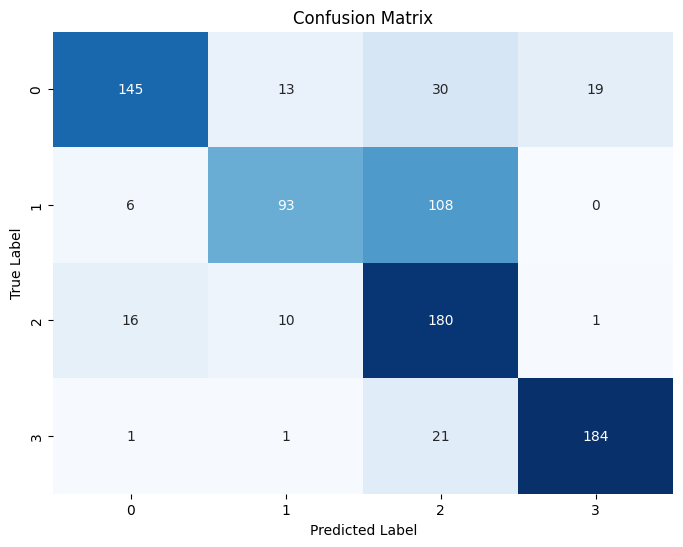

In [ ]:
# Generate and visualize confusion matrix for validation set
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Final Test Set Evaluation

Evaluate the trained model on the held-out test set to assess real-world performance. This provides:
- **Test Loss**: How well the model fits the test data
- **Test Accuracy**: Overall classification accuracy
- **Test Precision**: Proportion of positive predictions that are correct
- **Test Recall**: Proportion of actual positives correctly identified
- **Confusion Matrix**: Detailed per-class performance
- **Classification Report**: Per-class precision, recall, and F1-scores

FINAL TEST SET EVALUATION
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - accuracy: 0.7626 - loss: 0.6887 - precision: 0.7895 - recall: 0.6444

Test Loss: 0.7163
Test Accuracy: 0.7418
Test Precision: 0.7667
Test Recall: 0.6326
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 255ms/step


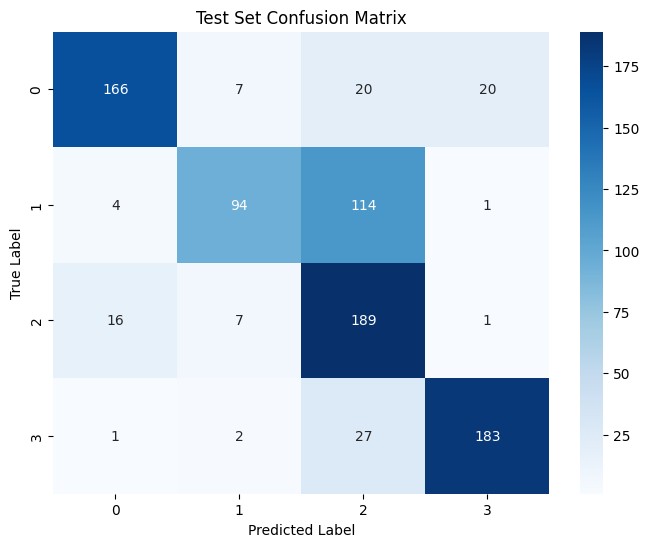


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.89      0.78      0.83       213
           1       0.85      0.44      0.58       213
           2       0.54      0.89      0.67       213
           3       0.89      0.86      0.88       213

    accuracy                           0.74       852
   macro avg       0.79      0.74      0.74       852
weighted avg       0.79      0.74      0.74       852



In [ ]:
# Final evaluation on TEST set (held-out data)
print("="*50)
print("FINAL TEST SET EVALUATION")
print("="*50)

# Evaluate the model to get loss, accuracy, precision, and recall
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_subset_ds)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

# Confusion matrix for test set
y_test_pred_probs = model.predict(test_subset_ds)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)
y_test_true = np.concatenate([np.argmax(y, axis=1) for x, y in test_subset_ds], axis=0)

# Compute and plot confusion matrix
cm_test = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Set Confusion Matrix')
plt.show()

# Classification report
from sklearn.metrics import classification_report
print("\nClassification Report (Test Set):")
print(classification_report(y_test_true, y_test_pred))

## ROC Curves and AUC Scores

ROC (Receiver Operating Characteristic) curves visualize the trade-off between true positive rate and false positive rate for each class.

I use a one-vs-rest approach, plotting a separate ROC curve for each of the 4 classes.

27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step


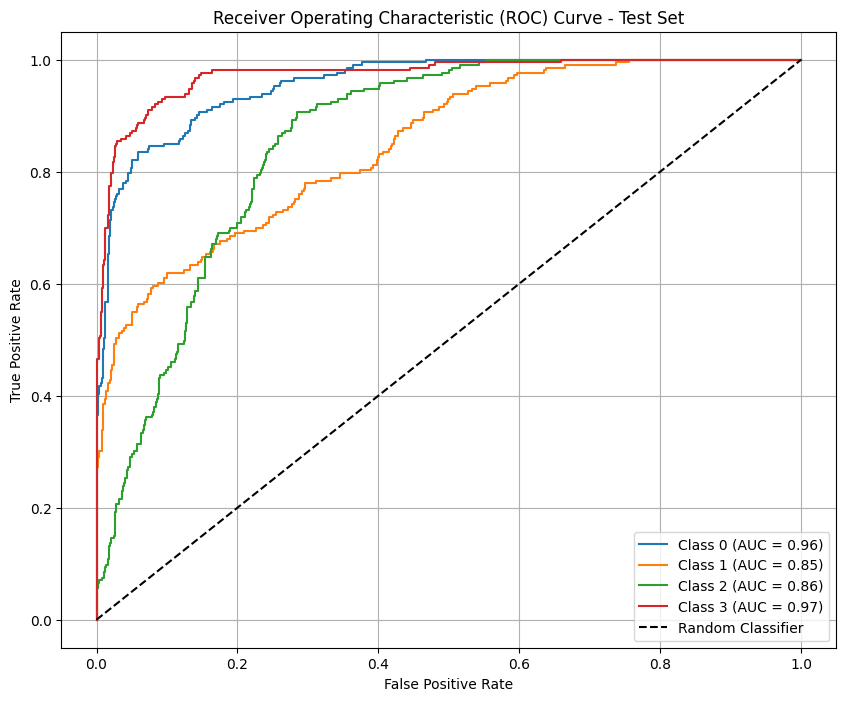

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Get true labels and predicted probabilities from the test set
y_true_test = np.concatenate([y.numpy() for x, y in test_subset_ds], axis=0)
y_pred_proba_test = model.predict(test_subset_ds)

# Assuming 4 classes (adjust if different)
num_classes = 4

# Binarize the true labels for ROC calculation (one-vs-rest approach)
y_true_binarized = label_binarize(np.argmax(y_true_test, axis=1), classes=range(num_classes))

# Plot ROC curve for each class
plt.figure(figsize=(10, 8))

for i in range(num_classes):
    # Calculate ROC curve: False Positive Rate vs True Positive Rate
    fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_pred_proba_test[:, i])

    # Calculate Area Under the Curve (AUC)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

# Plot diagonal line representing random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Test Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()